In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [2]:
horses0 = pd.read_csv('./data/horses.csv', low_memory=False)
horses1 = pd.read_csv('./data/horses1.csv', low_memory=False)
horses2 = pd.read_csv('./data/horses2.csv', low_memory=False)


In [3]:
def horses_preprocess(dfs):
    dfs_processed = []
    for df in dfs:
        # Create a copy to avoid SettingWithCopyWarning
        df_processed = df[['Winner','StartingOdds','RecentWinPercent','Class','laststart']].copy()
        df_processed.fillna(df_processed.median(), inplace=True)
        dfs_processed.append(df_processed)
    return pd.concat(dfs_processed, axis=0)
horses = horses_preprocess([horses1, horses2, horses0])

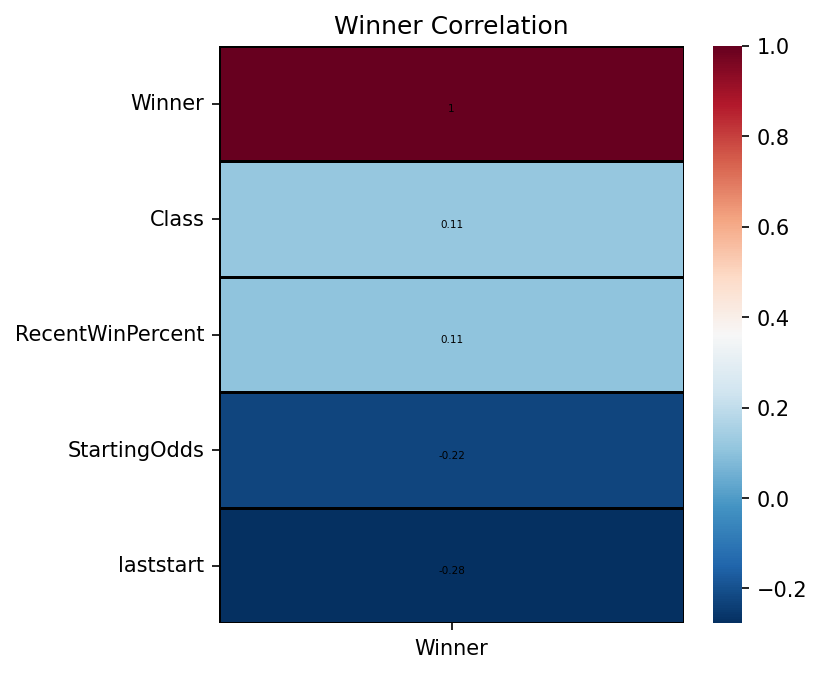

In [4]:
corr = horses.corr().sort_values(by='Winner', ascending=False)
winner_corr = corr[['Winner']]
fig, ax = plt.subplots(figsize=(5,5), dpi=150)
annot_kws = {"ha": 'center',"va": 'top', "size":5, "color": "black"}
ax = sns.heatmap(winner_corr, 
                 annot=True, 
                 vmax=winner_corr.max(), 
                 vmin=winner_corr.min(), 
                 square=False, cbar=True, 
                 cmap='RdBu_r', 
                 linewidths=0.5, 
                 linecolor='black', 
                 annot_kws=annot_kws)
ax.set_title('Winner Correlation')
plt.show()

In [5]:
horses.info(verbose=True, show_counts=True)


<class 'pandas.core.frame.DataFrame'>
Index: 1220095 entries, 0 to 640514
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Winner            1220095 non-null  float64
 1   StartingOdds      1220095 non-null  float64
 2   RecentWinPercent  1220095 non-null  float64
 3   Class             1220095 non-null  float64
 4   laststart         1220095 non-null  float64
dtypes: float64(5)
memory usage: 55.9 MB


In [6]:
x = horses.drop(['Winner'], axis=1)
y = horses['Winner']
x = pd.DataFrame(StandardScaler().fit_transform(x), columns=x.columns)
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=53)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)


In [7]:
lr = LogisticRegression(solver='newton-cg').fit(x_train, y_train)
print(f'Logistic Regression: {round(lr.score(x_test, y_test)*100)}%')


Logistic Regression: 91%


In [8]:
input = tf.keras.Input(shape=(x.shape[1],))
x = tf.keras.layers.Dense(8, activation='relu')(input)
x = tf.keras.layers.Dense(4, activation='relu')(x)
output = tf.keras.layers.Dense(1, activation='sigmoid')(x)
nn_model = tf.keras.Model(input, output)
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
nn_model.fit(x_train, y_train, epochs=10, validation_data=(x_val, y_val), verbose=1)


Epoch 1/10
34316/34316 ━━━━━━━━━━━━━━━━━━━━ 21s 597us/step - accuracy: 0.8966 - loss: 0.2614 - val_accuracy: 0.9193 - val_loss: 0.2161
Epoch 2/10
34316/34316 ━━━━━━━━━━━━━━━━━━━━ 19s 558us/step - accuracy: 0.9178 - loss: 0.2153 - val_accuracy: 0.9186 - val_loss: 0.2080
Epoch 3/10
34316/34316 ━━━━━━━━━━━━━━━━━━━━ 19s 548us/step - accuracy: 0.9215 - loss: 0.2074 - val_accuracy: 0.9219 - val_loss: 0.2051
Epoch 4/10
34316/34316 ━━━━━━━━━━━━━━━━━━━━ 21s 598us/step - accuracy: 0.9229 - loss: 0.2051 - val_accuracy: 0.9246 - val_loss: 0.2023
Epoch 5/10
34316/34316 ━━━━━━━━━━━━━━━━━━━━ 20s 574us/step - accuracy: 0.9226 - loss: 0.2043 - val_accuracy: 0.9239 - val_loss: 0.2017
Epoch 6/10
34316/34316 ━━━━━━━━━━━━━━━━━━━━ 20s 585us/step - accuracy: 0.9233 - loss: 0.2032 - val_accuracy: 0.9244 - val_loss: 0.2034
Epoch 7/10
34316/34316 ━━━━━━━━━━━━━━━━━━━━ 21s 611us/step - accuracy: 0.9238 - loss: 0.2026 - val_accuracy: 0.9231 - val_loss: 0.2006
Epoch 8/10
34316/34316 ━━━━━━━━━━━━━━━━━━━━ 20s 569us/s

In [9]:
nn_model.evaluate(x_test, y_test)


3813/3813 ━━━━━━━━━━━━━━━━━━━━ 2s 459us/step - accuracy: 0.9261 - loss: 0.1983


[0.20077958703041077, 0.9252028465270996]

In [10]:
nn_model.save('./model/nn_model.keras')